# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

# Preprocesameinto de la variable objetivo 

Aplicar una transformación logarítmica a tu variable `casos_dengue` no solo es adecuado, sino que en este caso es **altamente recomendable**.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from copy import deepcopy

In [3]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados"
ubicacion_datos_consolidados_marco = ""
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos"
ubicacion_imagenes_marco = ""

In [4]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\datos_semanal_meteo_epi.xlsx"
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_semanal_meteo_epi.xlsx"
datos_semanal_meteo_epi = pd.read_excel(path_janis)
# hacer que fecha sea el indice y sea de tipo datetime
datos_semanal_meteo_epi['fecha'] = pd.to_datetime(datos_semanal_meteo_epi['fecha']) # convertir en tipo datetime
datos_semanal_meteo_epi.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
datos_semanal_meteo_epi.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst,casos_dengue
fecha,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214,0
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352,0
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407,1
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360,0
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892,0


In [5]:
datos_semanal_meteo_epi.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue'],
      dtype='object')

In [6]:
datos_semanal_meteo_epi['casos_dengue'] 

fecha
2021-01-03    0
2021-01-10    0
2021-01-17    1
2021-01-24    0
2021-01-31    0
             ..
2025-11-30    8
2025-12-07    9
2025-12-14    7
2025-12-21    5
2025-12-28    9
Name: casos_dengue, Length: 261, dtype: int64

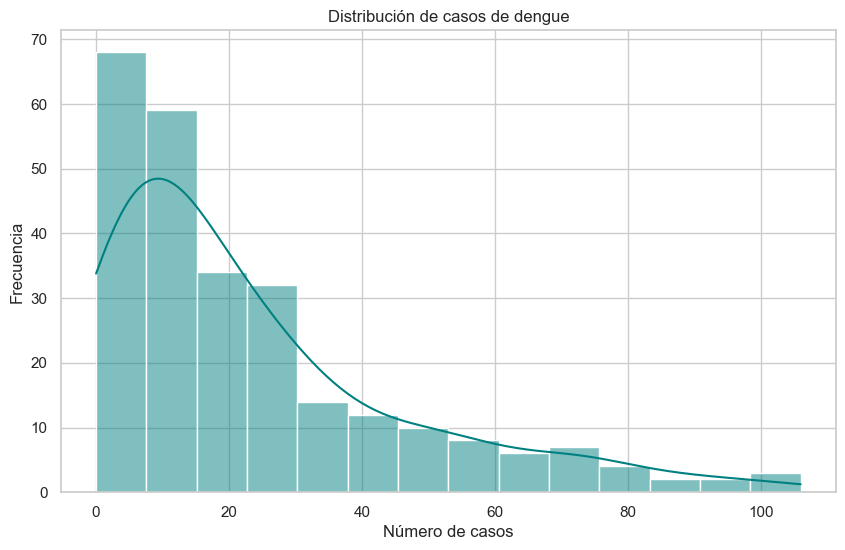

In [7]:
# Graficar el histograma de la variables casos_dengue 

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(datos_semanal_meteo_epi['casos_dengue'], kde=True, color='teal')

plt.title('Distribución de casos de dengue')
plt.xlabel('Número de casos')
plt.ylabel('Frecuencia')
plt.savefig(f"{ubicacion_imagenes_janis}/1.preprocesamiento_histograma_casos_dengue.png", dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
datos_transformados = datos_semanal_meteo_epi.copy()

# 1. Transformaciones (primero)
datos_transformados['casos_ln']       = np.log(datos_transformados['casos_dengue'] + 1)
datos_transformados['prec_ln']        = np.log(datos_transformados['prec'] + 1)
datos_transformados['dias_lluvia_ln'] = np.log(datos_transformados['dias_lluvia'] + 1)

# Box-Cox para variables positivas
vars_boxcox = ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
               'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv']

for var in vars_boxcox:
    datos_transformados[f'{var}_bc'], _ = boxcox(datos_transformados[var])

# Yeo-Johnson para variables con negativos
pt = PowerTransformer(method='yeo-johnson')
datos_transformados['soi_yj'] = pt.fit_transform(datos_transformados[['soi']])
datos_transformados['sst_yj'] = pt.fit_transform(datos_transformados[['sst']])
print("✅ Transformaciones aplicadas correctamente")
print("Columnas transformadas:", [col for col in datos_transformados.columns if col.endswith(('_ln', '_bc', '_yj'))])


✅ Transformaciones aplicadas correctamente
Columnas transformadas: ['casos_ln', 'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc', 'soi_yj', 'sst_yj']


In [22]:
# 2. Crear 16 rezagos (después de transformar)
variables_para_lags = ['casos_ln', 'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc', 'soi_yj', 'sst_yj'] 

for var in variables_para_lags:
    for lag in range(1, 17):   # 1 a 16 rezagos
        datos_transformados[f'{var}_lag{lag}'] = datos_transformados[var].shift(lag)

# 3. (Opcional) Estandarización de los predictores después de los rezagos
from sklearn.preprocessing import StandardScaler

lag_columns = [col for col in datos_transformados.columns if '_lag' in col]
scaler = StandardScaler()
datos_transformados[lag_columns] = scaler.fit_transform(datos_transformados[lag_columns])

# Eliminar filas con NaN generadas por los rezagos
datos_transformados = datos_transformados.dropna().reset_index(drop=True)

C:\Users\usuario1\AppData\Local\Temp\ipykernel_19196\4278533029.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  datos_transformados[f'{var}_lag{lag}'] = datos_transformados[var].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19196\4278533029.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  datos_transformados[f'{var}_lag{lag}'] = datos_transformados[var].shift(lag)
C:\Users\usuario1\AppData\Local\Temp\ipykernel_19196\4278533029.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resul

In [9]:
datos_transformados.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,temp_max_bc,temp_min_bc,hum_esp_bc,hum_rel_bc,vel_vi_bc,vel_vi_max_bc,vel_vi_min_bc,uv_bc,soi_yj,sst_yj
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,0.172149,1.250461,49402.390213,6.524308e+09,-2.286820,-1.055463,-1.741313,0.992455,1.432593,-1.726035
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,0.172149,1.252005,63332.512049,7.845750e+09,-2.418425,-1.220807,-1.796327,1.013891,1.251647,-1.721237
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,0.172149,1.251559,46242.048185,4.128765e+09,-2.300693,-1.158569,-1.750046,1.124647,0.545162,-1.403882
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,0.172149,1.252023,52072.378241,5.281850e+09,-2.300693,-1.177561,-1.816253,1.161999,0.983127,-1.181283
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,0.172149,1.254023,63217.760675,6.026010e+09,-2.357997,-1.162336,-1.859133,1.038080,0.403642,-1.323334


In [10]:
datos_transformados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc',
       'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
       'soi_yj', 'sst_yj'],
      dtype='object')


Calculando correlaciones cruzadas...



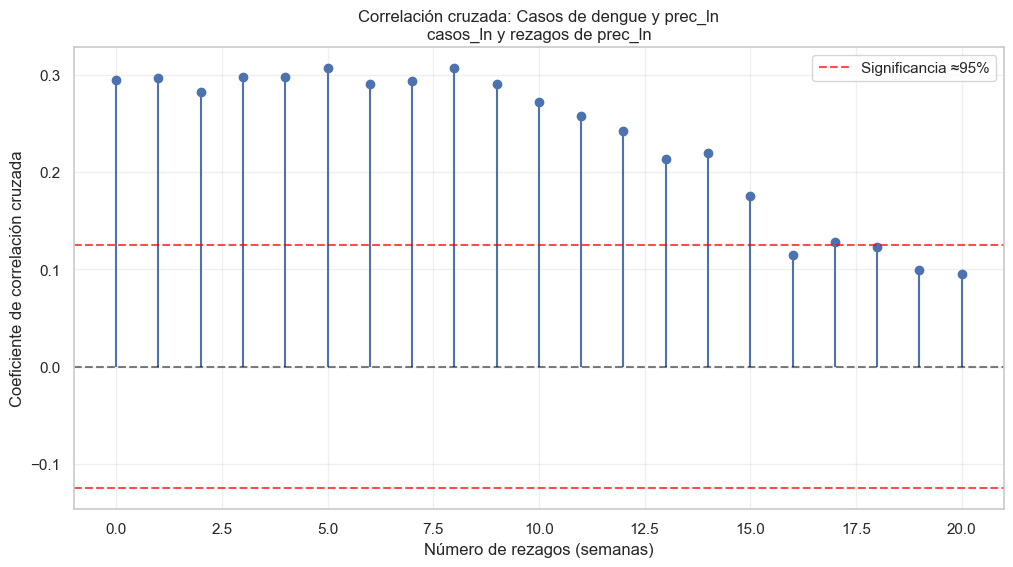


=== Rezagos más relevantes para casos_ln vs prec_ln ===
Lag  1: +0.2965
Lag  2: +0.2829
Lag  3: +0.2976
Lag  4: +0.2979
Lag  5: +0.3069
Lag  6: +0.2903
Lag  7: +0.2933
Lag  8: +0.3067
Lag  9: +0.2907
Lag 10: +0.2722
Lag 11: +0.2580
Lag 12: +0.2421
Lag 13: +0.2140
Lag 14: +0.2193
Lag 15: +0.1753


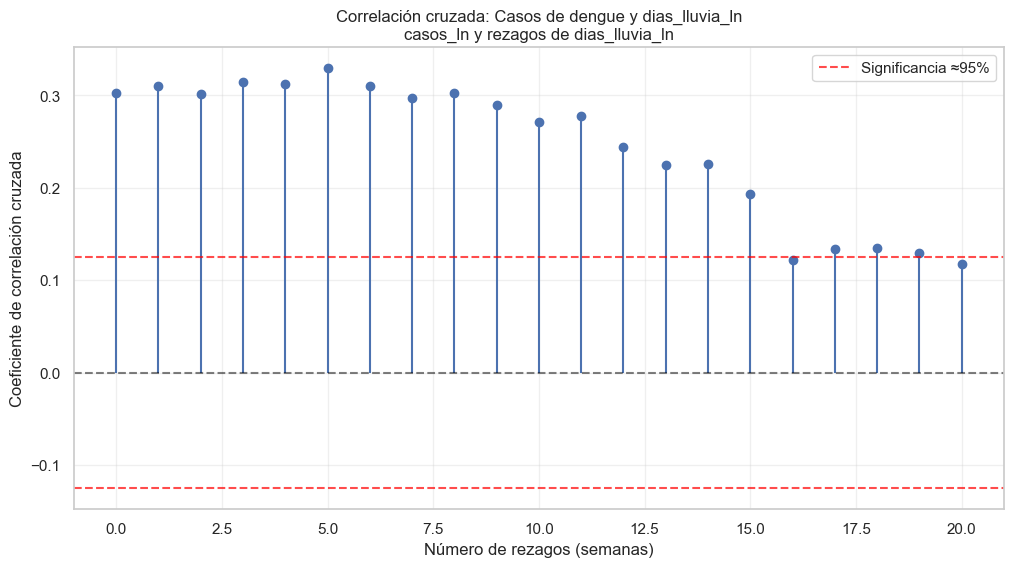


=== Rezagos más relevantes para casos_ln vs dias_lluvia_ln ===
Lag  1: +0.3097
Lag  2: +0.3014
Lag  3: +0.3149
Lag  4: +0.3125
Lag  5: +0.3293
Lag  6: +0.3097
Lag  7: +0.2966
Lag  8: +0.3026
Lag  9: +0.2896
Lag 10: +0.2714
Lag 11: +0.2777
Lag 12: +0.2442
Lag 13: +0.2245
Lag 14: +0.2261
Lag 15: +0.1929


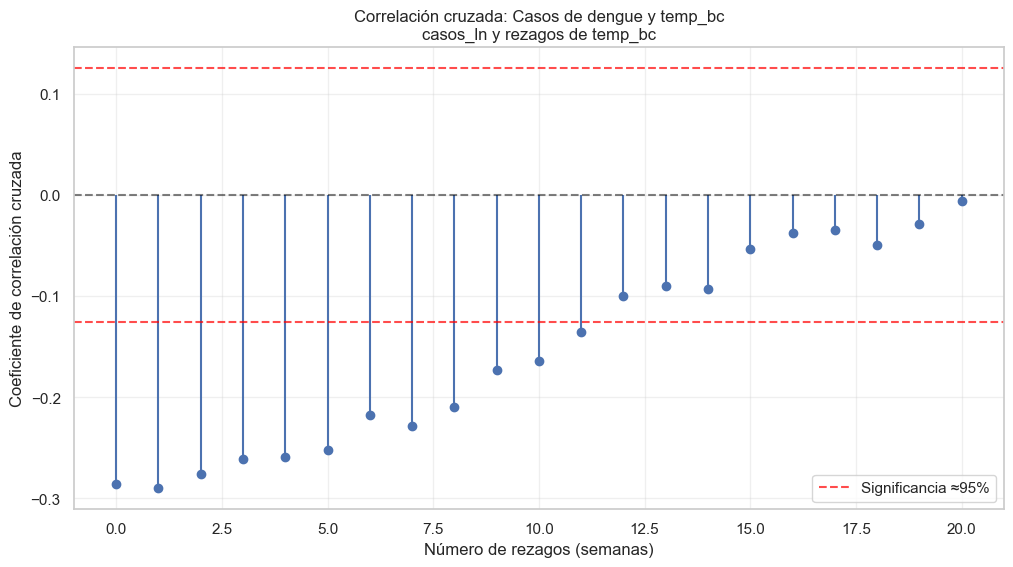


=== Rezagos más relevantes para casos_ln vs temp_bc ===
Lag  1: -0.2901
Lag  2: -0.2764
Lag  3: -0.2614
Lag  4: -0.2592
Lag  5: -0.2518
Lag  6: -0.2179
Lag  7: -0.2287
Lag  8: -0.2092
Lag  9: -0.1731
Lag 10: -0.1641


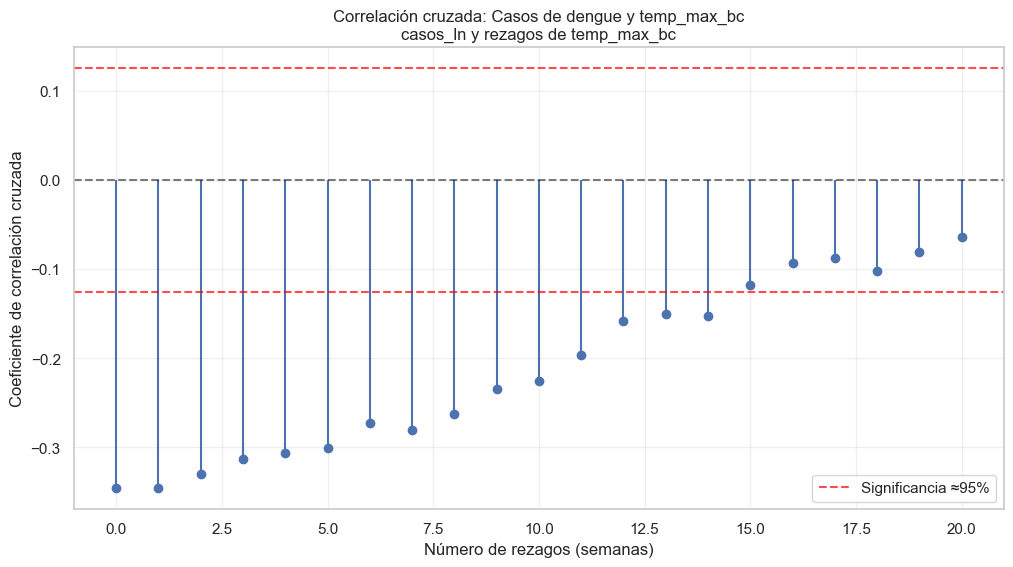


=== Rezagos más relevantes para casos_ln vs temp_max_bc ===
Lag  1: -0.3458
Lag  2: -0.3302
Lag  3: -0.3125
Lag  4: -0.3065
Lag  5: -0.3001
Lag  6: -0.2722
Lag  7: -0.2809
Lag  8: -0.2624
Lag  9: -0.2349
Lag 10: -0.2255
Lag 11: -0.1964
Lag 12: -0.1585
Lag 13: -0.1503
Lag 14: -0.1530


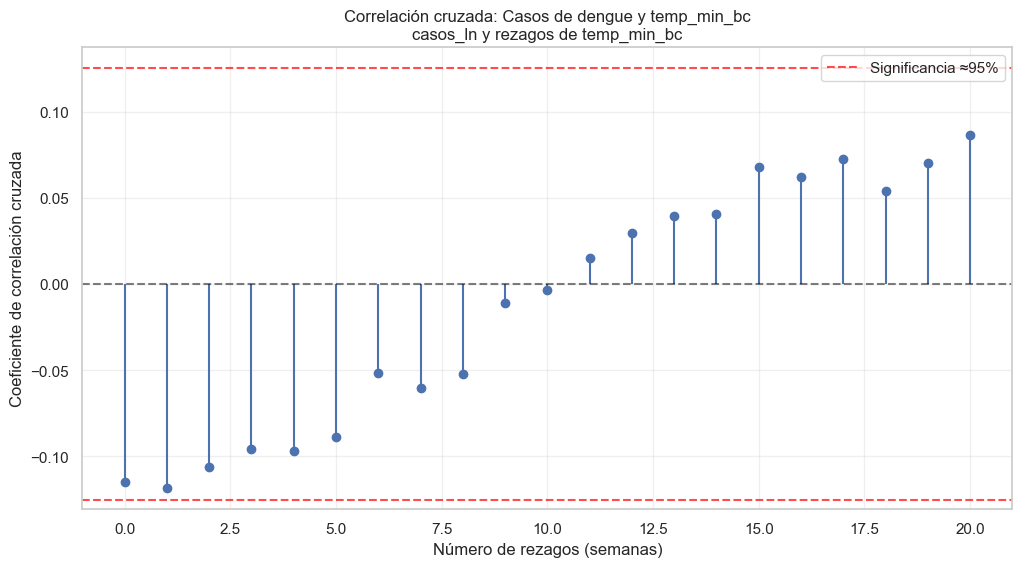


=== Rezagos más relevantes para casos_ln vs temp_min_bc ===


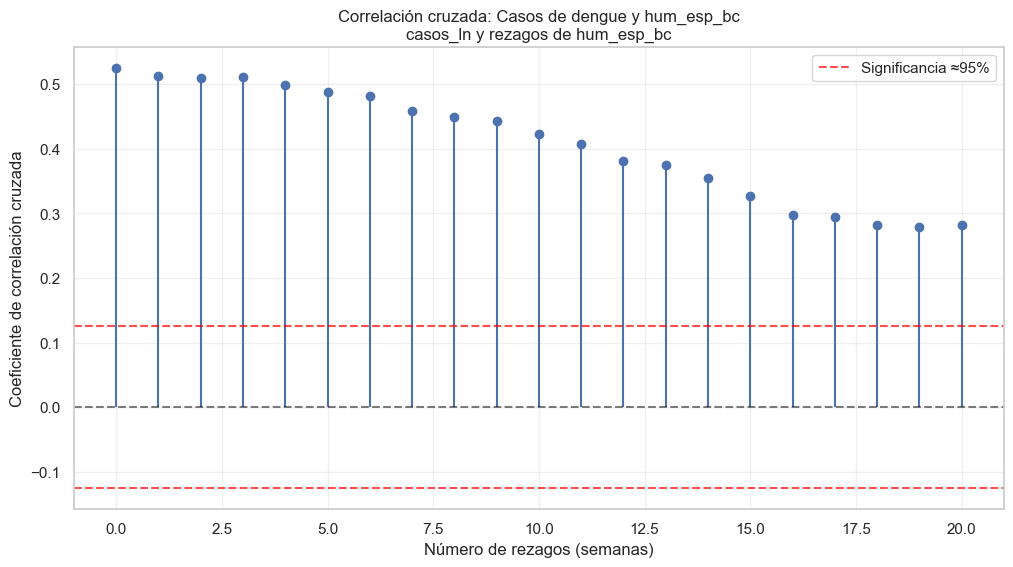


=== Rezagos más relevantes para casos_ln vs hum_esp_bc ===
Lag  1: +0.5127
Lag  2: +0.5095
Lag  3: +0.5103
Lag  4: +0.4979
Lag  5: +0.4876
Lag  6: +0.4815
Lag  7: +0.4584
Lag  8: +0.4497
Lag  9: +0.4423
Lag 10: +0.4222
Lag 11: +0.4075
Lag 12: +0.3816
Lag 13: +0.3753
Lag 14: +0.3550
Lag 15: +0.3273
Lag 16: +0.2978
Lag 17: +0.2937
Lag 18: +0.2818
Lag 19: +0.2792
Lag 20: +0.2814


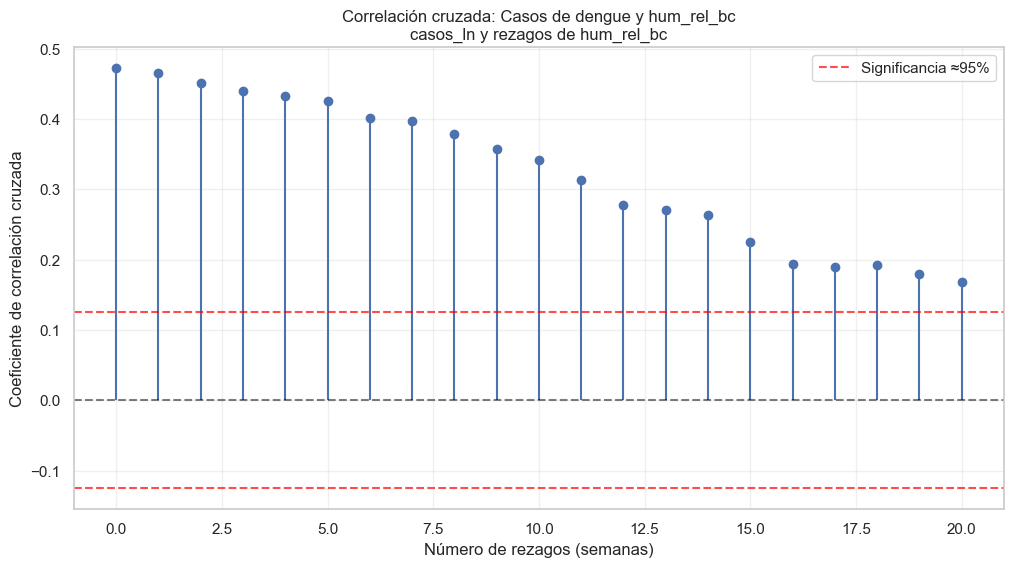


=== Rezagos más relevantes para casos_ln vs hum_rel_bc ===
Lag  1: +0.4656
Lag  2: +0.4513
Lag  3: +0.4397
Lag  4: +0.4325
Lag  5: +0.4259
Lag  6: +0.4017
Lag  7: +0.3973
Lag  8: +0.3789
Lag  9: +0.3569
Lag 10: +0.3410
Lag 11: +0.3135
Lag 12: +0.2778
Lag 13: +0.2700
Lag 14: +0.2636
Lag 15: +0.2245
Lag 16: +0.1931
Lag 17: +0.1901
Lag 18: +0.1919
Lag 19: +0.1791
Lag 20: +0.1686


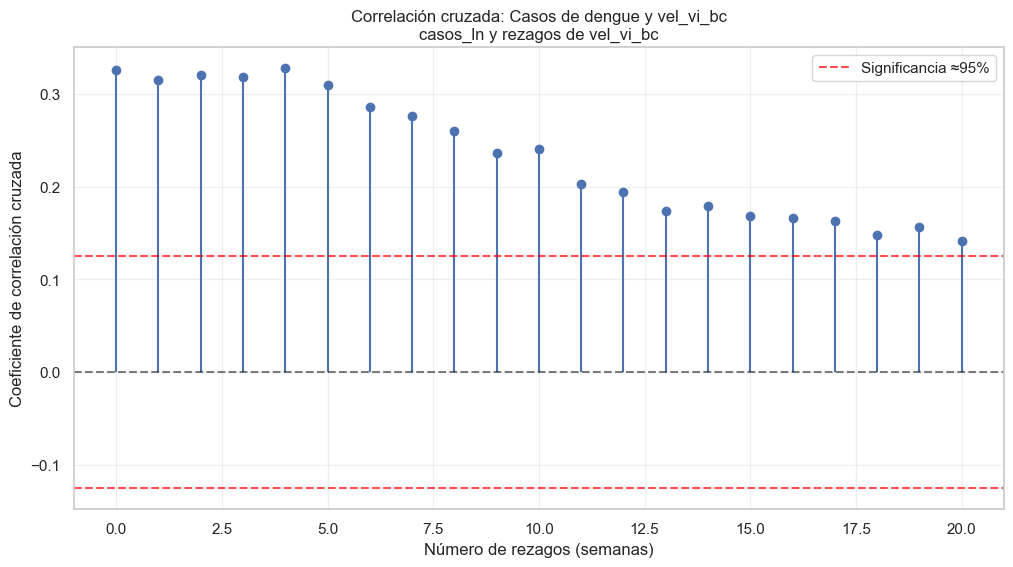


=== Rezagos más relevantes para casos_ln vs vel_vi_bc ===
Lag  1: +0.3155
Lag  2: +0.3202
Lag  3: +0.3180
Lag  4: +0.3277
Lag  5: +0.3099
Lag  6: +0.2861
Lag  7: +0.2757
Lag  8: +0.2597
Lag  9: +0.2368
Lag 10: +0.2402
Lag 11: +0.2034
Lag 12: +0.1946
Lag 13: +0.1741
Lag 14: +0.1794
Lag 15: +0.1681
Lag 16: +0.1659
Lag 17: +0.1625
Lag 19: +0.1565


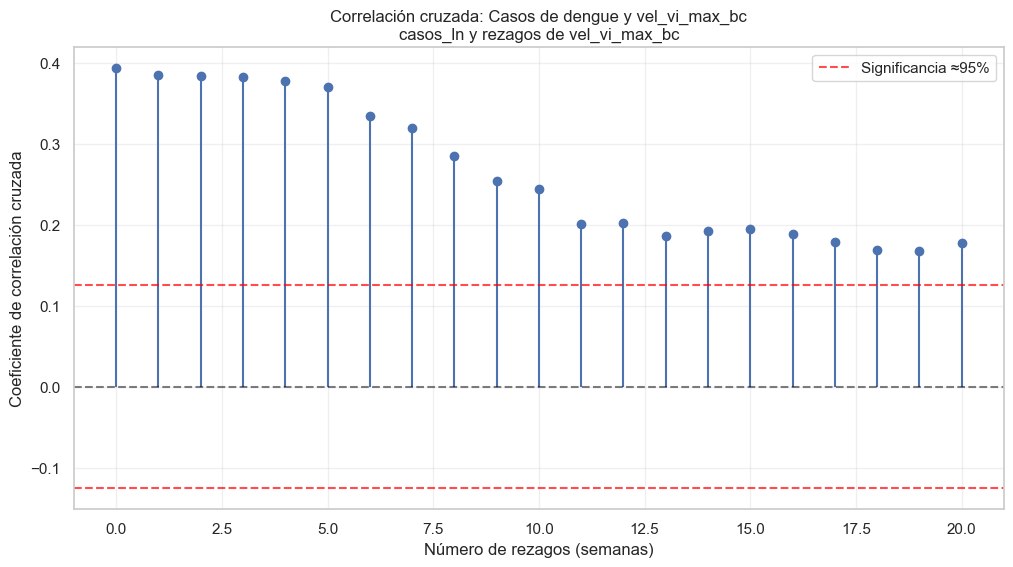


=== Rezagos más relevantes para casos_ln vs vel_vi_max_bc ===
Lag  1: +0.3844
Lag  2: +0.3832
Lag  3: +0.3822
Lag  4: +0.3773
Lag  5: +0.3697
Lag  6: +0.3347
Lag  7: +0.3195
Lag  8: +0.2843
Lag  9: +0.2537
Lag 10: +0.2440
Lag 11: +0.2004
Lag 12: +0.2024
Lag 13: +0.1858
Lag 14: +0.1919
Lag 15: +0.1952
Lag 16: +0.1882
Lag 17: +0.1789
Lag 18: +0.1682
Lag 19: +0.1678
Lag 20: +0.1773


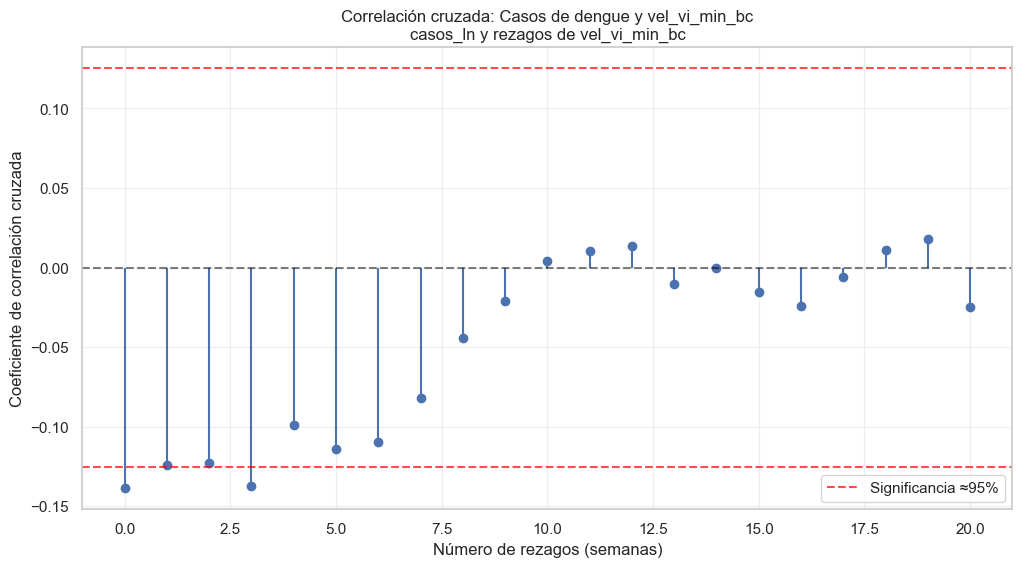


=== Rezagos más relevantes para casos_ln vs vel_vi_min_bc ===


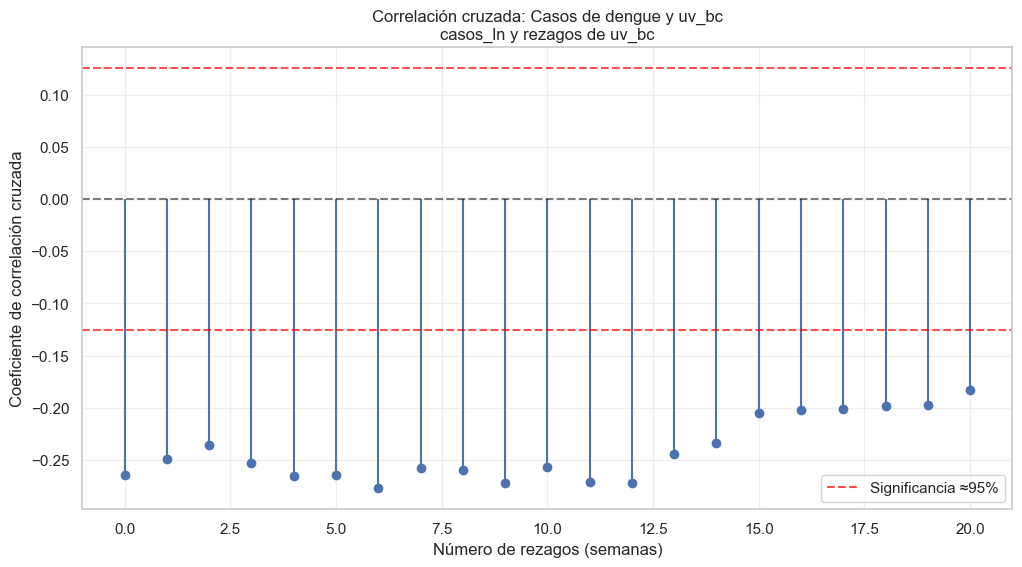


=== Rezagos más relevantes para casos_ln vs uv_bc ===
Lag  1: -0.2489
Lag  2: -0.2354
Lag  3: -0.2531
Lag  4: -0.2653
Lag  5: -0.2643
Lag  6: -0.2769
Lag  7: -0.2576
Lag  8: -0.2598
Lag  9: -0.2717
Lag 10: -0.2561
Lag 11: -0.2706
Lag 12: -0.2722
Lag 13: -0.2444
Lag 14: -0.2339
Lag 15: -0.2053
Lag 16: -0.2017
Lag 17: -0.2007
Lag 18: -0.1980
Lag 19: -0.1969
Lag 20: -0.1829


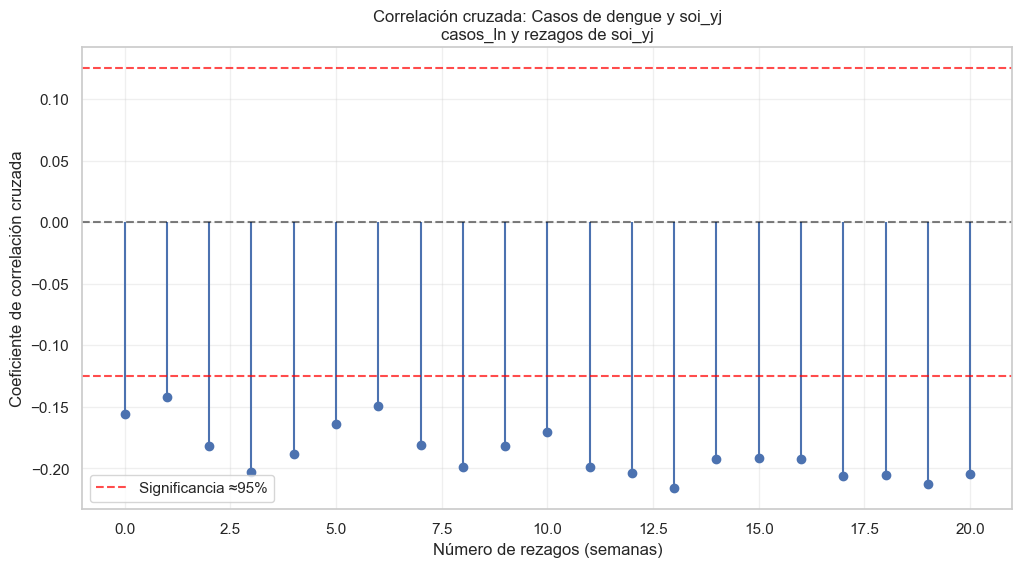


=== Rezagos más relevantes para casos_ln vs soi_yj ===
Lag  2: -0.1816
Lag  3: -0.2027
Lag  4: -0.1881
Lag  5: -0.1642
Lag  7: -0.1812
Lag  8: -0.1987
Lag  9: -0.1816
Lag 10: -0.1705
Lag 11: -0.1992
Lag 12: -0.2035
Lag 13: -0.2162
Lag 14: -0.1927
Lag 15: -0.1916
Lag 16: -0.1926
Lag 17: -0.2060
Lag 18: -0.2057
Lag 19: -0.2128
Lag 20: -0.2047


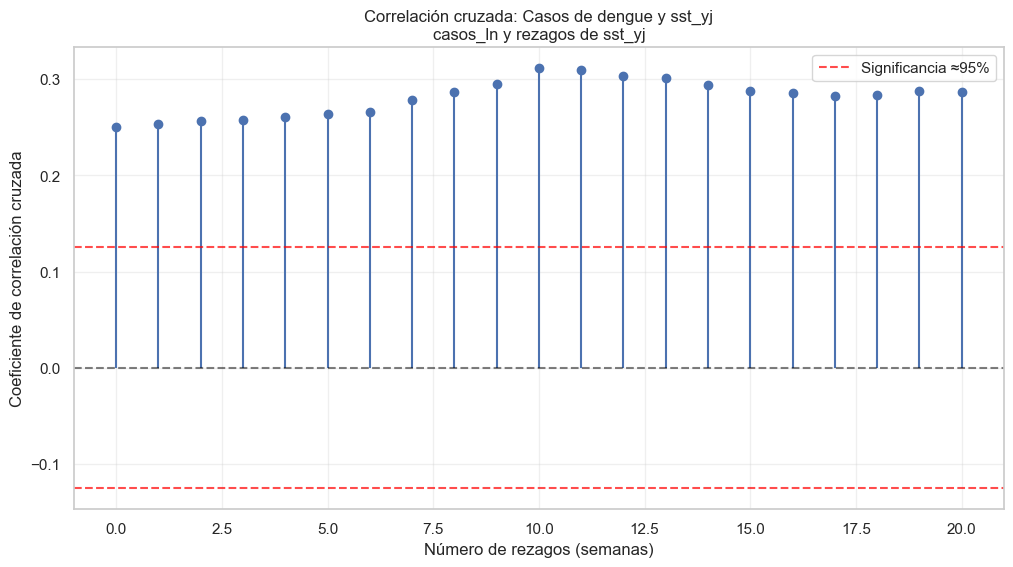


=== Rezagos más relevantes para casos_ln vs sst_yj ===
Lag  1: +0.2538
Lag  2: +0.2564
Lag  3: +0.2580
Lag  4: +0.2605
Lag  5: +0.2638
Lag  6: +0.2653
Lag  7: +0.2788
Lag  8: +0.2866
Lag  9: +0.2950
Lag 10: +0.3113
Lag 11: +0.3095
Lag 12: +0.3028
Lag 13: +0.3009
Lag 14: +0.2938
Lag 15: +0.2873
Lag 16: +0.2857
Lag 17: +0.2822
Lag 18: +0.2836
Lag 19: +0.2876
Lag 20: +0.2864


In [24]:
# ====================== 3. Función para calcular y graficar CCF ====================== 
def plot_cross_correlation(df, var_x, var_y, max_lags=20, title=""):
    """
    Calcula y grafica la correlación cruzada entre dos series
    """
    x = df[var_x].values
    y = df[var_y].values
    
    # Calcular correlación cruzada
    correlation = signal.correlate(y - np.mean(y), x - np.mean(x), mode='full')
    lags = signal.correlation_lags(len(y), len(x), mode='full')
    
    # Normalizar
    correlation = correlation / (np.std(y) * np.std(x) * len(y))
    
    # Solo lags positivos (0 en adelante)
    pos_mask = lags >= 0
    lags_pos = lags[pos_mask][:max_lags+1]
    corr_pos = correlation[pos_mask][:max_lags+1]
    
    # Graficar
    plt.figure(figsize=(12, 6))
    plt.stem(lags_pos, corr_pos, basefmt=" ")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7, label='Significancia ≈95%')
    plt.axhline(y=-1.96/np.sqrt(len(y)), color='red', linestyle='--', alpha=0.7)
    
    plt.title(f'Correlación cruzada: {title}\n{var_y} y rezagos de {var_x}')
    plt.xlabel('Número de rezagos (semanas)')
    plt.ylabel('Coeficiente de correlación cruzada')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Mostrar rezagos relevantes
    print(f"\n=== Rezagos más relevantes para {var_y} vs {var_x} ===")
    for i in range(1, max_lags+1):
        if abs(corr_pos[i]) > 0.15:
            sign = "+" if corr_pos[i] > 0 else ""
            print(f"Lag {i:2d}: {sign}{corr_pos[i]:.4f}")


# ====================== 4. Crear copia para rezagos ======================
datos_transformados_rezagos = datos_transformados.copy()


# ====================== 5. Calcular CCF para las variables ======================
variables_a_analizar = [
    'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc',
    'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc',
    'vel_vi_min_bc', 'uv_bc', 'soi_yj', 'sst_yj'
]

print("\nCalculando correlaciones cruzadas...\n")

for var in variables_a_analizar:
    plot_cross_correlation(
        datos_transformados_rezagos,
        var_x=var,
        var_y='casos_ln',
        max_lags=20,
        title=f"Casos de dengue y {var}"
    )

In [19]:
datos_transformados_rezagos.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc',
       'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
       'soi_yj', 'sst_yj'],
      dtype='object')

In [26]:
import pandas as pd

# Datos de la tabla de rezagos relevantes
data = {
    'Variable': [
        'hum_esp_bc', 'hum_rel_bc', 'vel_vi_max_bc', 'temp_max_bc', 
        'vel_vi_bc', 'dias_lluvia_ln', 'prec_ln', 'temp_bc', 
        'sst_yj', 'uv_bc', 'soi_yj', 'vel_vi_min_bc'
    ],
    'Rezagos más fuertes': [
        'Lag 1: +0.5946, Lag 2: +0.5932, Lag 3: +0.5943',
        'Lag 1: +0.5603, Lag 2: +0.5509, Lag 3: +0.5414',
        'Lag 1: +0.4669, Lag 2: +0.4651, Lag 3: +0.4662',
        'Lag 1: -0.4525, Lag 2: -0.4425',
        'Lag 4: +0.4136, Lag 2: +0.4070',
        'Lag 5: +0.4175, Lag 4: +0.4096',
        'Lag 5: +0.3784, Lag 8: +0.3778',
        'Lag 1: -0.3988, Lag 2: -0.3912',
        'Lag 10: +0.3944, Lag 9: +0.3843',
        'Lag 11: -0.2639, Lag 6: -0.2632',
        'Lag 13: -0.2138',
        'Lag 3: -0.2198'
    ],
    'Correlación más alta': [
        '+0.5946', '+0.5603', '+0.4669', '-0.4525',
        '+0.4136', '+0.4175', '+0.3784', '-0.3988',
        '+0.3944', '-0.2639', '-0.2138', '-0.2198'
    ],
    'Tipo de correlación': [
        'Muy fuerte positiva', 'Muy fuerte positiva', 'Fuerte positiva',
        'Fuerte negativa', 'Moderada positiva', 'Moderada positiva',
        'Moderada positiva', 'Moderada negativa', 'Moderada positiva (retrasada)',
        'Débil negativa', 'Débil negativa', 'Débil negativa'
    ]
}

# Crear el DataFrame
tabla_rezagos = pd.DataFrame(data)

# Mostrar la tabla de forma bonita en Jupyter / VS Code
display(tabla_rezagos)

# Opcional: Guardar como Excel o CSV para tenerla siempre
tabla_rezagos.to_excel(ubicacion_datos_consolidados_janis + '/rezagos_relevantes_dengue.xlsx', index=False)

print("✅ Tabla creada y guardada como 'rezagos_relevantes_dengue.xlsx'")

,Variable,Rezagos más fuertes,Correlación más alta,Tipo de correlación
0,hum_esp_bc,"Lag 1: +0.5946, Lag 2: +0.5932, Lag 3: +0.5943",+0.5946,Muy fuerte positiva
1,hum_rel_bc,"Lag 1: +0.5603, Lag 2: +0.5509, Lag 3: +0.5414",+0.5603,Muy fuerte positiva
2,vel_vi_max_bc,"Lag 1: +0.4669, Lag 2: +0.4651, Lag 3: +0.4662",+0.4669,Fuerte positiva
3,temp_max_bc,"Lag 1: -0.4525, Lag 2: -0.4425",-0.4525,Fuerte negativa
4,vel_vi_bc,"Lag 4: +0.4136, Lag 2: +0.4070",+0.4136,Moderada positiva
5,dias_lluvia_ln,"Lag 5: +0.4175, Lag 4: +0.4096",+0.4175,Moderada positiva
6,prec_ln,"Lag 5: +0.3784, Lag 8: +0.3778",+0.3784,Moderada positiva
7,temp_bc,"Lag 1: -0.3988, Lag 2: -0.3912",-0.3988,Moderada negativa
8,sst_yj,"Lag 10: +0.3944, Lag 9: +0.3843",+0.3944,Moderada positiva (retrasada)
9,uv_bc,"Lag 11: -0.2639, Lag 6: -0.2632",-0.2639,Débil negativa


✅ Tabla creada y guardada como 'rezagos_relevantes_dengue.xlsx'


In [25]:
import pandas as pd

# Datos actualizados con recomendación
data = {
    'Variable': [
        'hum_esp_bc', 
        'hum_rel_bc', 
        'vel_vi_max_bc', 
        'temp_max_bc', 
        'vel_vi_bc', 
        'dias_lluvia_ln', 
        'prec_ln', 
        'temp_bc', 
        'sst_yj', 
        'uv_bc', 
        'soi_yj', 
        'vel_vi_min_bc'
    ],
    'Correlación más alta': [
        '+0.5946', '+0.5603', '+0.4669', '-0.4525', 
        '+0.4136', '+0.4175', '+0.3784', '-0.3988', 
        '+0.3944', '-0.2639', '-0.2138', '-0.2198'
    ],
    'Rezagos clave': [
        '1,2,3', '1,2,3', '1,2,3', '1,2', 
        '2,4', '4,5', '5,8', '1,2', 
        '9,10,11', '6,11', '13', '3'
    ],
    'Recomendación de rezagos a usar': [
        'Lags 1 al 6', 
        'Lags 1 al 6', 
        'Lags 1 al 5', 
        'Lags 1 al 4', 
        'Lags 1 al 6', 
        'Lags 1 al 8', 
        'Lags 4 al 8', 
        'Lags 1 al 4', 
        'Lags 8 al 12', 
        'Lags 5 al 12 (opcional)', 
        'Lag 10 al 15 (opcional)', 
        'No recomendado (débil)'
    ],
    'Tipo de correlación': [
        'Muy fuerte positiva', 
        'Muy fuerte positiva', 
        'Fuerte positiva', 
        'Fuerte negativa', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada positiva', 
        'Moderada negativa', 
        'Moderada positiva (retrasada)', 
        'Débil negativa', 
        'Débil negativa', 
        'Débil negativa'
    ]
}

# Crear la tabla
tabla_rezagos = pd.DataFrame(data)

# Mostrar tabla bonita en Jupyter / VS Code
styled_table = tabla_rezagos.style.set_caption("📊 Rezagos relevantes según correlación cruzada con casos_ln") \
                                 .set_properties(**{'text-align': 'left'}) \
                                 .background_gradient(subset=['Correlación más alta'], cmap='RdYlGn')

display(styled_table)

# Guardar en archivos (útil para tenerla siempre)
tabla_rezagos.to_excel(ubicacion_datos_consolidados_janis + '/rezagos_relevantes_dengue.xlsx', index=False)

print("✅ Tabla creada y guardada exitosamente como:")
print("rezagos_relevantes_dengue.xlsx")

,Variable,Correlación más alta,Rezagos clave,Recomendación de rezagos a usar,Tipo de correlación
0,hum_esp_bc,+0.5946,"1,2,3",Lags 1 al 6,Muy fuerte positiva
1,hum_rel_bc,+0.5603,"1,2,3",Lags 1 al 6,Muy fuerte positiva
2,vel_vi_max_bc,+0.4669,"1,2,3",Lags 1 al 5,Fuerte positiva
3,temp_max_bc,-0.4525,"1,2",Lags 1 al 4,Fuerte negativa
4,vel_vi_bc,+0.4136,"2,4",Lags 1 al 6,Moderada positiva
5,dias_lluvia_ln,+0.4175,"4,5",Lags 1 al 8,Moderada positiva
6,prec_ln,+0.3784,"5,8",Lags 4 al 8,Moderada positiva
7,temp_bc,-0.3988,"1,2",Lags 1 al 4,Moderada negativa
8,sst_yj,+0.3944,"9,10,11",Lags 8 al 12,Moderada positiva (retrasada)
9,uv_bc,-0.2639,"6,11",Lags 5 al 12 (opcional),Débil negativa


✅ Tabla creada y guardada exitosamente como:
rezagos_relevantes_dengue.xlsx


## Prueba de normalidad

In [23]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = datos_transformados.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.899026,9.284377e-12,False
temp_max,0.865911,8.149160e-14,False
temp_min,0.982967,4.935323e-03,False
hum_esp,0.948597,1.319516e-07,False
hum_rel,0.812586,1.755733e-16,False
...,...,...,...
sst_yj_lag12,0.961391,3.692201e-06,False
sst_yj_lag13,0.960384,2.783825e-06,False
sst_yj_lag14,0.959277,2.050007e-06,False
sst_yj_lag15,0.958822,1.810456e-06,False


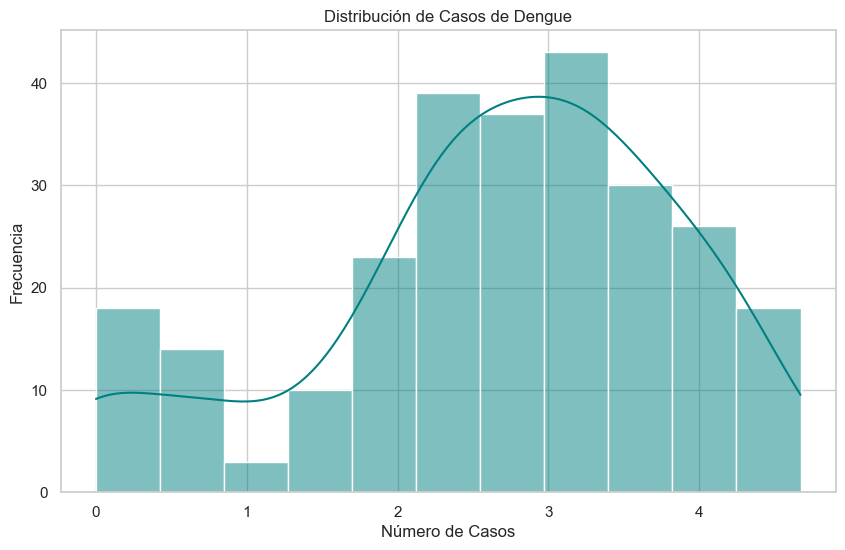

In [26]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(np.log(1 + datos_semanal_meteo_epi['casos_dengue']), kde=True, color='teal')

plt.title('Distribución de Casos de Dengue')
plt.xlabel('Número de Casos')
plt.ylabel('Frecuencia')
#plt.savefig(ubicacion_imagenes_janis + "/2_histograma_casos_dengue_aplicado_ln.png")
plt.show()


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()